In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install --upgrade "dask[dataframe]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 17.7 MB/s eta 0:00:00
  Attempting uninstall: dask
    Found existing installation: dask 2025.5.0
    Uninstalling dask-2025.5.0:
      Successfully uninstalled dask-2025.5.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
distributed 2025.5.0 requires dask==2025.5.0, but you have dask 2025.7.0 which is incompatible.
rapids-dask-dependency 25.6.0 requires dask==2025.5.0, but you have dask 2025.7.0 which is incompatible.


In [ ]:
!pip install --upgrade "dask[distributed]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.8 MB/s eta 0:00:00
  Attempting uninstall: distributed
    Found existing installation: distributed 2025.5.0
    Uninstalling distributed-2025.5.0:
      Successfully uninstalled distributed-2025.5.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rapids-dask-dependency 25.6.0 requires dask==2025.5.0, but you have dask 2025.7.0 which is incompatible.
rapids-dask-dependency 25.6.0 requires distributed==2025.5.0, but you have distributed 2025.7.0 which is incompatible.


In [ ]:
!pip install --upgrade pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 22.3 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 21.0.0 which is incompatible.
cudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 21.0.0 which is incompatible.


In [ ]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
import sys

from dask.distributed import Client, LocalCluster

# Existe integração com pandas, então customização da configuração do pandas também funciona aqui

# Não limitar a largura das colunas apresentadas
pd.options.display.max_colwidth = None
# Não usar a notação científica (ex: 6.125000e-02) e usar 2 casas decimais (ex: 0.06)
pd.options.display.float_format = "{:.2f}".format

In [ ]:
# Criar cluster local anexado ao kernel do notebook
cluster = LocalCluster(n_workers=1)
client = Client(cluster)
client

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:38083
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:43993'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:37351 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:37351
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:57366
INFO:distributed.scheduler:Receive client connection: Client-7cfbc42e-8b2e-11f0-81b0-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:57380


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 1
Total threads: 2,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38083,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37351,Total threads: 2
Dashboard: http://127.0.0.1:35969/status,Memory: 12.67 GiB
Nanny: tcp://127.0.0.1:43993,


In [ ]:
# Descomente e execute as linhas abaixo para desligar o cluster

# client.close()
# cluster.close()

In [ ]:
ROOT_DATA_PATH = "drive/MyDrive/data"

## Explorando o dataset

In [ ]:
# Ler os dados de transações de bitcoin dos arquivos CSV
# Obs:
#     O primeiro * é porque existem várias pastas dentro da pasta bitcoin
#.    O segundo * é porque existem vários arquivos CSV dentro de cada uma dessas pastas

bitcoin_df = dd.read_csv(f'{ROOT_DATA_PATH}/bitcoin/*/*.csv')
bitcoin_df

,Height,Input,Output,Sum,Time
npartitions=46,,,,,
,int64,string,string,string,string
,...,...,...,...,...
...,...,...,...,...,...
,...,...,...,...,...
,...,...,...,...,...


In [ ]:
bitcoin_df.head()

,Height,Input,Output,Sum,Time
0,546,"['1DZTzaBHUDM7T3QvUKBz4qXMRpkg8jsfB5', '1DCbY2GYVaAMCBpuBNN5GVg3a47pNK1wdi']","['1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv', '1', '1DZTzaBHUDM7T3QvUKBz4qXMRpkg8jsfB5', '24']",['25'],2009-01-15 06:08:20
1,546,"['1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv', '1DZTzaBHUDM7T3QvUKBz4qXMRpkg8jsfB5']","['1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv', '25']",['25'],2009-01-15 06:08:20
2,546,['1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv'],"['1DZTzaBHUDM7T3QvUKBz4qXMRpkg8jsfB5', '1', '1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv', '24']",['25'],2009-01-15 06:08:20
3,586,"['1DNdPgBZRWjDj1JbVZQEYMv7jvqJF7R4Py', '1ELmSkQWnqgbBZNzxAZHts3MEYCngqRBeD', '1ADpf5rHERc2PmVAZZFoH7WbougKvkPDVD', '1ACWHyRM8rtbt96KauPJprnF2qDQSdPJ54', '1LfjLrBDYyPbvGMiD9jURxyAupdYujsBdK']","['19QKDUJtx9n7Vaga6nX1bVHdsnT4Khfyi6', '250']",['250'],2009-01-15 14:25:20
4,586,['1E5npMTmh9PnBHxCacuqzAZRGEybkxPMAq'],"['1QKJnFPvRoZ7avBhxqwxhsEv62JWYoB1R9', '50']",['50'],2009-01-15 14:25:20


In [ ]:
%%time

len(bitcoin_df)

CPU times: user 3.95 s, sys: 569 ms, total: 4.51 s
Wall time: 1min 35s


13494203

## Executando operações nos dados mais rapidamente com Parquet

In [ ]:
%%time

# Vamos salvar os dados de forma distribuída em arquivos Parquet para melhorar a performance

bitcoin_df.to_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet', overwrite=True, engine='pyarrow')

CPU times: user 4.69 s, sys: 716 ms, total: 5.4 s
Wall time: 1min 51s


In [ ]:
bitcoin_df = dd.read_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet', engine='pyarrow')
bitcoin_df

,Height,Input,Output,Sum,Time
npartitions=46,,,,,
,int64,string,string,string,string
,...,...,...,...,...
...,...,...,...,...,...
,...,...,...,...,...
,...,...,...,...,...


In [ ]:
%%time

len(bitcoin_df)

CPU times: user 50.4 ms, sys: 35.1 ms, total: 85.5 ms
Wall time: 239 ms


13494203

In [ ]:
bitcoin_df.head()

,Height,Input,Output,Sum,Time
0,546,"['1DZTzaBHUDM7T3QvUKBz4qXMRpkg8jsfB5', '1DCbY2GYVaAMCBpuBNN5GVg3a47pNK1wdi']","['1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv', '1', '1DZTzaBHUDM7T3QvUKBz4qXMRpkg8jsfB5', '24']",['25'],2009-01-15 06:08:20
1,546,"['1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv', '1DZTzaBHUDM7T3QvUKBz4qXMRpkg8jsfB5']","['1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv', '25']",['25'],2009-01-15 06:08:20
2,546,['1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv'],"['1DZTzaBHUDM7T3QvUKBz4qXMRpkg8jsfB5', '1', '1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv', '24']",['25'],2009-01-15 06:08:20
3,586,"['1DNdPgBZRWjDj1JbVZQEYMv7jvqJF7R4Py', '1ELmSkQWnqgbBZNzxAZHts3MEYCngqRBeD', '1ADpf5rHERc2PmVAZZFoH7WbougKvkPDVD', '1ACWHyRM8rtbt96KauPJprnF2qDQSdPJ54', '1LfjLrBDYyPbvGMiD9jURxyAupdYujsBdK']","['19QKDUJtx9n7Vaga6nX1bVHdsnT4Khfyi6', '250']",['250'],2009-01-15 14:25:20
4,586,['1E5npMTmh9PnBHxCacuqzAZRGEybkxPMAq'],"['1QKJnFPvRoZ7avBhxqwxhsEv62JWYoB1R9', '50']",['50'],2009-01-15 14:25:20


In [ ]:
len(bitcoin_df.partitions[0])

14832

In [ ]:
type(bitcoin_df.partitions[0])

dask.dataframe.dask_expr._collection.DataFrame

In [ ]:
bitcoin_df.npartitions

46

## Criando novas colunas

In [ ]:
%%time

bitcoin_df['Time'].head()

CPU times: user 44.9 ms, sys: 132 µs, total: 45 ms
Wall time: 233 ms


,Time
0,2009-01-15 06:08:20
1,2009-01-15 06:08:20
2,2009-01-15 06:08:20
3,2009-01-15 14:25:20
4,2009-01-15 14:25:20


In [ ]:
%%time

# A coluna 'Time' possui uma string que representa uma data e hora
# Vamos transformar a string em datetime com dd.to_datetime

bitcoin_df['Time'] = dd.to_datetime(bitcoin_df['Time'])
bitcoin_df['Date'] = bitcoin_df['Time'].dt.date.astype(str) # Criar uma coluna com a data da coluna 'Time'
bitcoin_df['Year'] = bitcoin_df['Time'].dt.year # Criar uma coluna com o ano da coluna 'Time'
bitcoin_df['Month'] = bitcoin_df['Time'].dt.month # Criar uma coluna com o mês da coluna 'Time'
bitcoin_df['Day'] = bitcoin_df['Time'].dt.day # Criar uma coluna com o dia da coluna 'Time'
bitcoin_df['Weekday'] = bitcoin_df['Time'].dt.weekday # Criar uma coluna com o dia da semana da coluna 'Time'

CPU times: user 19.9 ms, sys: 0 ns, total: 19.9 ms
Wall time: 22 ms


In [ ]:
bitcoin_df.head(3)

,Height,Input,Output,Sum,Time,Date,Year,Month,Day,Weekday
0,546,"['1DZTzaBHUDM7T3QvUKBz4qXMRpkg8jsfB5', '1DCbY2GYVaAMCBpuBNN5GVg3a47pNK1wdi']","['1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv', '1', '1DZTzaBHUDM7T3QvUKBz4qXMRpkg8jsfB5', '24']",['25'],2009-01-15 06:08:20,2009-01-15,2009,1,15,3
1,546,"['1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv', '1DZTzaBHUDM7T3QvUKBz4qXMRpkg8jsfB5']","['1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv', '25']",['25'],2009-01-15 06:08:20,2009-01-15,2009,1,15,3
2,546,['1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv'],"['1DZTzaBHUDM7T3QvUKBz4qXMRpkg8jsfB5', '1', '1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv', '24']",['25'],2009-01-15 06:08:20,2009-01-15,2009,1,15,3


In [ ]:
bitcoin_df

,Height,Input,Output,Sum,Time,Date,Year,Month,Day,Weekday
npartitions=46,,,,,,,,,,
,float64,string,string,string,datetime64[ns],object,int32,int32,int32,int32
,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...


In [ ]:
%%time

bitcoin_df.to_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet_new_cols', overwrite=True, engine='pyarrow')

CPU times: user 4.75 s, sys: 664 ms, total: 5.42 s
Wall time: 1min 27s


In [ ]:
bitcoin_df = dd.read_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet_new_cols', engine='pyarrow')
bitcoin_df

,Height,Input,Output,Sum,Time,Date,Year,Month,Day,Weekday
npartitions=46,,,,,,,,,,
,float64,string,string,string,datetime64[ns],string,int32,int32,int32,int32
,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...


In [ ]:
bitcoin_df.head()

,Height,Input,Output,Sum,Time,Date,Year,Month,Day,Weekday
0,546.00,"['1DZTzaBHUDM7T3QvUKBz4qXMRpkg8jsfB5', '1DCbY2GYVaAMCBpuBNN5GVg3a47pNK1wdi']","['1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv', '1', '1DZTzaBHUDM7T3QvUKBz4qXMRpkg8jsfB5', '24']",['25'],2009-01-15 06:08:20,2009-01-15,2009,1,15,3
1,546.00,"['1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv', '1DZTzaBHUDM7T3QvUKBz4qXMRpkg8jsfB5']","['1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv', '25']",['25'],2009-01-15 06:08:20,2009-01-15,2009,1,15,3
2,546.00,['1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv'],"['1DZTzaBHUDM7T3QvUKBz4qXMRpkg8jsfB5', '1', '1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv', '24']",['25'],2009-01-15 06:08:20,2009-01-15,2009,1,15,3
3,586.00,"['1DNdPgBZRWjDj1JbVZQEYMv7jvqJF7R4Py', '1ELmSkQWnqgbBZNzxAZHts3MEYCngqRBeD', '1ADpf5rHERc2PmVAZZFoH7WbougKvkPDVD', '1ACWHyRM8rtbt96KauPJprnF2qDQSdPJ54', '1LfjLrBDYyPbvGMiD9jURxyAupdYujsBdK']","['19QKDUJtx9n7Vaga6nX1bVHdsnT4Khfyi6', '250']",['250'],2009-01-15 14:25:20,2009-01-15,2009,1,15,3
4,586.00,['1E5npMTmh9PnBHxCacuqzAZRGEybkxPMAq'],"['1QKJnFPvRoZ7avBhxqwxhsEv62JWYoB1R9', '50']",['50'],2009-01-15 14:25:20,2009-01-15,2009,1,15,3


In [ ]:
%%time

# Vamos pegar a Series da coluna 'Time' e filtrar somente valores que o dia da semana é 0 para ver qual dia da semana é
# Para verificar o dia da semana de uma data pesquise no Google usando o exemplo "day of 2010-01-25"
# Obs: a função where retorna o valor NaT (Not a Time) quando a condição não é atendida, por isso é utilizado o dropna

t = bitcoin_df['Time']
t.where(t.dt.weekday == 0).dropna().head()

CPU times: user 80.8 ms, sys: 5.72 ms, total: 86.5 ms
Wall time: 462 ms


,Time
76,2010-01-25 07:36:04
77,2010-01-25 07:36:04
84,2010-02-01 01:47:30
85,2010-02-01 01:47:30
102,2010-02-08 12:47:42


In [ ]:
# Também é possível fazer o mesmo filtro usando o modo clássico do pandas

bitcoin_df[bitcoin_df['Time'].dt.weekday == 0]['Time'].head()

,Time
76,2010-01-25 07:36:04
77,2010-01-25 07:36:04
84,2010-02-01 01:47:30
85,2010-02-01 01:47:30
102,2010-02-08 12:47:42


In [ ]:
# Também é possível selecionar as colunas 'Time' e 'Weekday' e apresentar somente os valores onde Weekday é 0

t_df = bitcoin_df[['Time', 'Weekday']]
t_df.where(t_df['Weekday'] == 0).dropna().head()

,Time,Weekday
76,2010-01-25 07:36:04,0.00
77,2010-01-25 07:36:04,0.00
84,2010-02-01 01:47:30,0.00
85,2010-02-01 01:47:30,0.00
102,2010-02-08 12:47:42,0.00


## Limpando os dados

In [ ]:
bitcoin_df.head()

,Height,Input,Output,Sum,Time,Date,Year,Month,Day,Weekday
0,546.00,"['1DZTzaBHUDM7T3QvUKBz4qXMRpkg8jsfB5', '1DCbY2GYVaAMCBpuBNN5GVg3a47pNK1wdi']","['1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv', '1', '1DZTzaBHUDM7T3QvUKBz4qXMRpkg8jsfB5', '24']",['25'],2009-01-15 06:08:20,2009-01-15,2009,1,15,3
1,546.00,"['1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv', '1DZTzaBHUDM7T3QvUKBz4qXMRpkg8jsfB5']","['1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv', '25']",['25'],2009-01-15 06:08:20,2009-01-15,2009,1,15,3
2,546.00,['1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv'],"['1DZTzaBHUDM7T3QvUKBz4qXMRpkg8jsfB5', '1', '1KAD5EnzzLtrSo2Da2G4zzD7uZrjk8zRAv', '24']",['25'],2009-01-15 06:08:20,2009-01-15,2009,1,15,3
3,586.00,"['1DNdPgBZRWjDj1JbVZQEYMv7jvqJF7R4Py', '1ELmSkQWnqgbBZNzxAZHts3MEYCngqRBeD', '1ADpf5rHERc2PmVAZZFoH7WbougKvkPDVD', '1ACWHyRM8rtbt96KauPJprnF2qDQSdPJ54', '1LfjLrBDYyPbvGMiD9jURxyAupdYujsBdK']","['19QKDUJtx9n7Vaga6nX1bVHdsnT4Khfyi6', '250']",['250'],2009-01-15 14:25:20,2009-01-15,2009,1,15,3
4,586.00,['1E5npMTmh9PnBHxCacuqzAZRGEybkxPMAq'],"['1QKJnFPvRoZ7avBhxqwxhsEv62JWYoB1R9', '50']",['50'],2009-01-15 14:25:20,2009-01-15,2009,1,15,3


In [ ]:
bitcoin_df.dtypes

,0
Height,float64
Input,string[pyarrow]
Output,string[pyarrow]
Sum,string[pyarrow]
Time,datetime64[ns]
Date,string[pyarrow]
Year,int32
Month,int32
Day,int32
Weekday,int32


In [ ]:
bitcoin_df.partitions[0]\
    .loc[0]\
    ['Sum'].compute()

,Sum
0,['25']


In [ ]:
# Tentar converter os valores da coluna Sum para float dá erro

bitcoin_df.partitions[0]\
    .loc[0]\
    ['Sum']\
    .astype(float)\
    .compute()

ValueError: could not convert string to float: "['25']"

In [ ]:
# É possível fazer um processamento de string para deixar apenas o número

"['25']".strip("[']")

'25'

In [ ]:
# Esse mesmo processamento de string pode ser feito em uma Series utilizando o atributo str

bitcoin_df['Sum'].str.strip("[']").head()

,Sum
0,25
1,25
2,25
3,250
4,50


In [ ]:
%%time

# Vamos testar um código de conversão para float apenas com a primeira partição

bitcoin_df.partitions[0]['Sum']\
    .str.strip("[']")\
    .astype(float)\
    .compute()

CPU times: user 41 ms, sys: 2.67 ms, total: 43.7 ms
Wall time: 77.5 ms


,Sum
0,25.00
1,25.00
2,25.00
3,250.00
4,50.00
...,...
14827,393.01
14828,0.05
14829,2.27
14830,2.22


In [ ]:
%%time

# Vamos confirmar toda a coluna 'Sum' pode ser convertida para float executando esse código
# em todas as partições

bitcoin_df['Sum']\
    .str.strip("[']")\
    .astype(float)\
    .sum()\
    .compute()

CPU times: user 353 ms, sys: 39.9 ms, total: 393 ms
Wall time: 6.21 s


np.float64(1329773312.799056)

In [ ]:
%%time

# Vejamos como remover as colunas 'Input' e 'Output' já que elas não serão utilizadas

bitcoin_df.drop(columns=['Input', 'Output']).head()

CPU times: user 52.6 ms, sys: 3.75 ms, total: 56.3 ms
Wall time: 233 ms


,Height,Sum,Time,Date,Year,Month,Day,Weekday
0,546.00,['25'],2009-01-15 06:08:20,2009-01-15,2009,1,15,3
1,546.00,['25'],2009-01-15 06:08:20,2009-01-15,2009,1,15,3
2,546.00,['25'],2009-01-15 06:08:20,2009-01-15,2009,1,15,3
3,586.00,['250'],2009-01-15 14:25:20,2009-01-15,2009,1,15,3
4,586.00,['50'],2009-01-15 14:25:20,2009-01-15,2009,1,15,3


In [ ]:
%%time

# Vejamos qual é a data mais antiga

bitcoin_df['Time'].min().compute()

CPU times: user 137 ms, sys: 10.6 ms, total: 148 ms
Wall time: 1.56 s


Timestamp('2009-01-15 06:08:20')

In [ ]:
%%time

# Vejamos qual é a data mais recente

bitcoin_df['Time'].max().compute()

CPU times: user 145 ms, sys: 11.8 ms, total: 157 ms
Wall time: 1.67 s


Timestamp('2014-03-13 09:37:24')

In [ ]:
%%time

# Vejamos quantos registros estão fora do intervalo desejado dos dados

len(bitcoin_df[(bitcoin_df['Time'] < '2009-01-01 00:00:00') |\
               (bitcoin_df['Time'] >= '2018-03-01 00:00:00')])

CPU times: user 271 ms, sys: 34.3 ms, total: 305 ms
Wall time: 3.46 s


0

In [ ]:
# Uma vez que todos os testes foram feitos, nós podemos simplificar o código de limpeza com o código abaixo

# Converter string de lista em float na coluna 'Sum'
bitcoin_df['Sum'] = bitcoin_df['Sum'].str.strip("[']").astype(float)

# Remover as colunas 'Input' e 'Output'
bitcoin_df = bitcoin_df.drop(columns=['Input', 'Output'])

# Filtrar somente os registros com valor válido na coluna 'Time'
bitcoin_df = bitcoin_df[(bitcoin_df['Time'] >= '2009-01-01 00:00:00') &\
                        (bitcoin_df['Time'] < '2018-03-01 00:00:00')]

In [ ]:
%%time

bitcoin_df.to_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet_clean', overwrite=True, engine='pyarrow')

CPU times: user 1.48 s, sys: 148 ms, total: 1.62 s
Wall time: 19.3 s


In [ ]:
bitcoin_df = dd.read_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet_clean', engine='pyarrow')
bitcoin_df

,Height,Sum,Time,Date,Year,Month,Day,Weekday
npartitions=23,,,,,,,,
,float64,float64,datetime64[ns],string,int32,int32,int32,int32
,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...


In [ ]:
%%time

len(bitcoin_df)

CPU times: user 32.3 ms, sys: 14.6 ms, total: 46.9 ms
Wall time: 118 ms


13494203

## Qual é a média de todas as transações?

In [ ]:
bitcoin_df.head()

,Height,Sum,Time,Date,Year,Month,Day,Weekday
0,546.00,25.00,2009-01-15 06:08:20,2009-01-15,2009,1,15,3
1,546.00,25.00,2009-01-15 06:08:20,2009-01-15,2009,1,15,3
2,546.00,25.00,2009-01-15 06:08:20,2009-01-15,2009,1,15,3
3,586.00,250.00,2009-01-15 14:25:20,2009-01-15,2009,1,15,3
4,586.00,50.00,2009-01-15 14:25:20,2009-01-15,2009,1,15,3


In [ ]:
%%time

bitcoin_df['Sum'].mean().compute()

CPU times: user 132 ms, sys: 15 ms, total: 147 ms
Wall time: 1.65 s


np.float64(98.54404241577332)

## Qual foi a quantidade de transações por ano? Ordene o resultado por ano

In [ ]:
%%time

bitcoin_df.groupby('Year')\
    ['Height']\
    .count()\
    .rename('Transactions_Count')\
    .reset_index()\
    .sort_values(by='Year')\
    .compute()

CPU times: user 142 ms, sys: 14 ms, total: 156 ms
Wall time: 1.71 s


,Year,Transactions_Count
0,2009,67
1,2010,107354
5,2011,1838723
2,2012,8400043
4,2013,3147755
3,2014,261


In [ ]:
%%time

# Vamos configurar o índice pela coluna 'Time' e ver se conseguimos ganho de performance

# Obs: eu verifiquei se configurando o índice pela coluna 'Year' era melhor, e confirmei
# que não é porque são criadas poucas partições. Nesse caso, resultou em estouro de memória
# nos workers. Mesmo que terminasse com sucesso, não é uma boa ideia poucas partições com tamanhos
# muito distintos.

bitcoin_df.set_index('Time')\
    .to_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet_time_idx', overwrite=True, engine='pyarrow')

CPU times: user 1.98 s, sys: 234 ms, total: 2.21 s
Wall time: 31.7 s


In [ ]:
bitcoin_df = dd.read_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet_time_idx', engine='pyarrow')
bitcoin_df

,Height,Sum,Date,Year,Month,Day,Weekday
npartitions=23,,,,,,,
,float64,float64,string,int32,int32,int32,int32
,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...
,...,...,...,...,...,...,...


In [ ]:
bitcoin_df.npartitions

23

In [ ]:
bitcoin_df.index.min().compute()

Timestamp('2009-01-15 06:08:20')

In [ ]:
bitcoin_df.head()

,Height,Sum,Date,Year,Month,Day,Weekday
Time,,,,,,,
2009-01-15 06:08:20,546.00,25.00,2009-01-15,2009,1,15,3
2009-01-15 06:08:20,546.00,25.00,2009-01-15,2009,1,15,3
2009-01-15 06:08:20,546.00,25.00,2009-01-15,2009,1,15,3
2009-01-15 14:25:20,586.00,250.00,2009-01-15,2009,1,15,3
2009-01-15 14:25:20,586.00,50.00,2009-01-15,2009,1,15,3


In [ ]:
bitcoin_df.index.max().compute()

Timestamp('2014-03-13 09:37:24')

In [ ]:
bitcoin_df.tail()

,Height,Sum,Date,Year,Month,Day,Weekday
Time,,,,,,,
2014-03-12 23:16:24,218024.00,8.55,2014-03-12,2014,3,12,2
2014-03-12 23:23:37,218972.00,0.48,2014-03-12,2014,3,12,2
2014-03-13 09:37:24,220500.00,200.93,2014-03-13,2014,3,13,3
2014-03-13 09:37:24,220500.00,13.89,2014-03-13,2014,3,13,3
2014-03-13 09:37:24,220500.00,20.68,2014-03-13,2014,3,13,3


In [ ]:
%%time

# O Dask ainda precisa olhar todas as partições porque o groupby é pela coluna 'Year'

bitcoin_df.groupby('Year')\
    ['Height']\
    .count()\
    .rename('Transactions_Count')\
    .reset_index()\
    .sort_values(by='Year')\
    .compute()

CPU times: user 144 ms, sys: 14.7 ms, total: 158 ms
Wall time: 1.75 s


,Year,Transactions_Count
0,2009,67
1,2010,107354
2,2011,1838723
3,2012,8400043
4,2013,3147755
5,2014,261


## Qual foi a quantidade de transações por data? Ordene o resultado por data

In [ ]:
bitcoin_df = dd.read_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet_clean', engine='pyarrow')
bitcoin_df

,Height,Sum,Time,Date,Year,Month,Day,Weekday
npartitions=23,,,,,,,,
,float64,float64,datetime64[ns],string,int32,int32,int32,int32
,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...


In [ ]:
%%time

bitcoin_df.groupby('Date')\
    ['Height']\
    .count()\
    .rename('Transactions_Count')\
    .reset_index()\
    .sort_values(by='Date')\
    .compute()

CPU times: user 192 ms, sys: 18.3 ms, total: 210 ms
Wall time: 2.57 s


,Date,Transactions_Count
0,2009-01-15,5
1,2009-02-03,13
2,2009-02-07,3
3,2009-02-22,4
4,2009-03-03,2
...,...,...
391,2013-03-03,12870
1011,2013-05-11,61
1012,2014-03-03,245
211,2014-03-12,13


In [ ]:
%%time

bitcoin_df.set_index('Date')\
    .to_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet_date_idx', overwrite=True, engine='pyarrow')

CPU times: user 2.34 s, sys: 300 ms, total: 2.64 s
Wall time: 42.9 s


In [ ]:
bitcoin_df = dd.read_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet_date_idx', engine='pyarrow')
bitcoin_df

,Height,Sum,Time,Year,Month,Day,Weekday
npartitions=23,,,,,,,
,float64,float64,datetime64[ns],int32,int32,int32,int32
,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...
,...,...,...,...,...,...,...


In [ ]:
bitcoin_df.head()

,Height,Sum,Time,Year,Month,Day,Weekday
Date,,,,,,,
2009-01-15,546.00,25.00,2009-01-15 06:08:20,2009,1,15,3
2009-01-15,546.00,25.00,2009-01-15 06:08:20,2009,1,15,3
2009-01-15,546.00,25.00,2009-01-15 06:08:20,2009,1,15,3
2009-01-15,586.00,250.00,2009-01-15 14:25:20,2009,1,15,3
2009-01-15,586.00,50.00,2009-01-15 14:25:20,2009,1,15,3


In [ ]:
%%time

bitcoin_df.groupby('Date')\
    ['Height']\
    .count()\
    .rename('Transactions_Count')\
    .reset_index()\
    .sort_values(by='Date')\
    .compute()

CPU times: user 191 ms, sys: 17.8 ms, total: 209 ms
Wall time: 2.92 s


,Date,Transactions_Count
0,2009-01-15,5
1,2009-02-03,13
2,2009-02-07,3
3,2009-02-22,4
4,2009-03-03,2
...,...,...
1122,2013-03-03,12870
1123,2013-05-11,61
1124,2014-03-03,245
1125,2014-03-12,13


## Quais foram as top 5 semanas com mais transações?

In [ ]:
bitcoin_df = dd.read_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet_clean', engine='pyarrow')
bitcoin_df

,Height,Sum,Time,Date,Year,Month,Day,Weekday
npartitions=23,,,,,,,,
,float64,float64,datetime64[ns],string,int32,int32,int32,int32
,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...


In [ ]:
bitcoin_df.head()

,Height,Sum,Time,Date,Year,Month,Day,Weekday
0,546.00,25.00,2009-01-15 06:08:20,2009-01-15,2009,1,15,3
1,546.00,25.00,2009-01-15 06:08:20,2009-01-15,2009,1,15,3
2,546.00,25.00,2009-01-15 06:08:20,2009-01-15,2009,1,15,3
3,586.00,250.00,2009-01-15 14:25:20,2009-01-15,2009,1,15,3
4,586.00,50.00,2009-01-15 14:25:20,2009-01-15,2009,1,15,3


In [ ]:
%%time

# Com o map_partitions a função lambda é executada em todas as partições em paralelo

bitcoin_df.map_partitions(lambda x: len(x))\
    .compute()\
    .nlargest(5)

CPU times: user 318 ms, sys: 31.8 ms, total: 350 ms
Wall time: 3.91 s


,0
0,698731
0,631710
0,623785
0,615443
0,615041


In [ ]:
%%time

# Vamos utilizar a indexação por 'Time' junto com o repartition por semana para ter uma semana
# em cada partição

bitcoin_df.set_index('Time')\
    .repartition(freq='W')\
    .to_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet_week_idx', overwrite=True, engine='pyarrow')

CPU times: user 3.99 s, sys: 380 ms, total: 4.37 s
Wall time: 40.1 s


In [ ]:
bitcoin_df = dd.read_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet_week_idx', engine='pyarrow')
bitcoin_df

,Height,Sum,Date,Year,Month,Day,Weekday
npartitions=270,,,,,,,
,float64,float64,string,int32,int32,int32,int32
,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...
,...,...,...,...,...,...,...


In [ ]:
%%time

# Agora podemos calcular a quantidade de registros em cada partição usando o map_partitions
# para depois pegar os top 5

bitcoin_df.map_partitions(lambda x: len(x))\
    .compute()\
    .nlargest(5)

CPU times: user 1.67 s, sys: 119 ms, total: 1.79 s
Wall time: 10.2 s


,0
0,429595
0,391142
0,388232
0,388196
0,366974


In [ ]:
# O índice da partição referente ao primeiro valor é 215

len(bitcoin_df.partitions[215])

429595

In [ ]:
bitcoin_df.partitions[0].compute().index.min()

Timestamp('2009-01-15 06:08:20')

In [ ]:
# Vamos ver a data mais antiga da partição com mais registros

bitcoin_df.partitions[215].compute().index.min()

Timestamp('2013-02-24 06:08:31')

In [ ]:
# Vamos ver a data mais recente da partição com mais registros

bitcoin_df.partitions[215].compute().index.max()

Timestamp('2013-03-03 05:56:57')

In [ ]:
# Vamos criar um metadata com o dicionário do dtypes do dataframe

metadata = bitcoin_df.dtypes.to_dict()
metadata

{'Height': dtype('float64'),
 'Sum': dtype('float64'),
 'Date': string[pyarrow],
 'Year': dtype('int32'),
 'Month': dtype('int32'),
 'Day': dtype('int32'),
 'Weekday': dtype('int32')}

In [ ]:
%%time

# Agora vamos pegar somente a primeira linha das top 5 semanas com mais registros
# Obs: no resultado final, a data no índice é o primeiro dia da semana correspondente ao
# 'Transactions_Count', sempre domingo

def count_transactions(df):
    df['Transactions_Count'] = len(df)
    return df[:1]

# Temos que adicionar no metadata a coluna que é criada na função passada no map_partitions
metadata['Transactions_Count'] = metadata['Weekday']
bitcoin_df.map_partitions(count_transactions, meta=metadata)\
    .nlargest(5, columns=['Transactions_Count'])\
    .compute()

CPU times: user 2.28 s, sys: 151 ms, total: 2.43 s
Wall time: 11.3 s


,Height,Sum,Date,Year,Month,Day,Weekday,Transactions_Count
Time,,,,,,,,
2013-02-24 06:08:31,222818.00,0.03,2013-02-24,2013,2,24,6,429595
2013-02-17 06:08:20,221615.00,2.81,2013-02-17,2013,2,17,6,391142
2013-02-10 06:08:21,220458.00,0.01,2013-02-10,2013,2,10,6,388232
2013-02-03 06:08:20,219355.00,0.05,2013-02-03,2013,2,3,6,388196
2013-01-27 06:08:21,218240.00,0.04,2013-01-27,2013,1,27,6,366974


## Qual é a quantidade de transações por ano e mês?

In [ ]:
bitcoin_df = dd.read_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet_clean', engine='pyarrow')
bitcoin_df

,Height,Sum,Time,Date,Year,Month,Day,Weekday
npartitions=23,,,,,,,,
,float64,float64,datetime64[ns],string,int32,int32,int32,int32
,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...


In [ ]:
bitcoin_df.head()

,Height,Sum,Time,Date,Year,Month,Day,Weekday
0,546.00,25.00,2009-01-15 06:08:20,2009-01-15,2009,1,15,3
1,546.00,25.00,2009-01-15 06:08:20,2009-01-15,2009,1,15,3
2,546.00,25.00,2009-01-15 06:08:20,2009-01-15,2009,1,15,3
3,586.00,250.00,2009-01-15 14:25:20,2009-01-15,2009,1,15,3
4,586.00,50.00,2009-01-15 14:25:20,2009-01-15,2009,1,15,3


CPU times: user 276 ms, sys: 31.3 ms, total: 308 ms
Wall time: 2.39 s


<Axes: xlabel='Year,Month'>

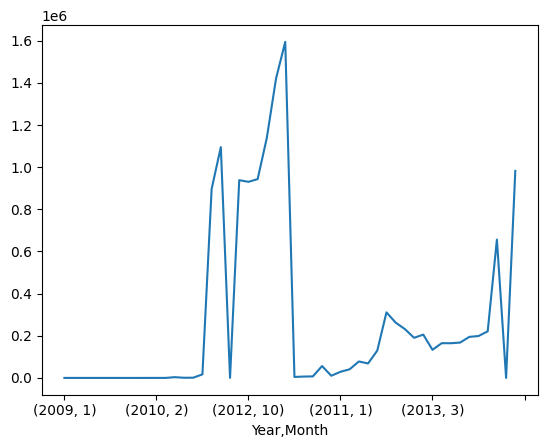

In [ ]:
%%time

# Os dados carregados da pasta bitcoin_parquet_clean não estão devidamente ordenados
# Obs: no pandas o uso do groupby como feito nesse código iria ordenar os dados por padrão,
# não é o caso do Dask

bitcoin_df.groupby(['Year', 'Month'])\
    ['Height']\
    .count()\
    .rename('Transactions_Count')\
    .compute()\
    .plot()

CPU times: user 210 ms, sys: 18.6 ms, total: 229 ms
Wall time: 2.23 s


<Axes: xlabel='Year,Month'>

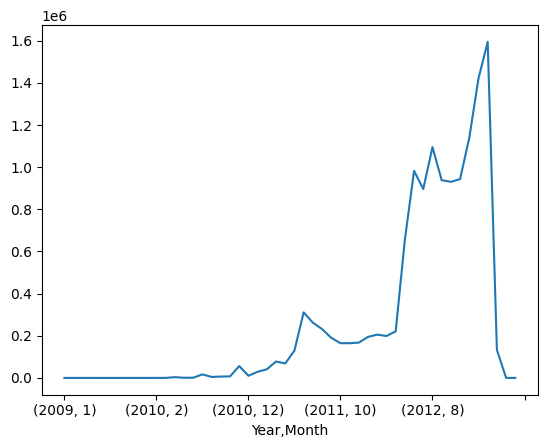

In [ ]:
%%time

# Para ordenar os dados é possível usar o argumento sort

bitcoin_df.groupby(['Year', 'Month'], sort=True)\
    ['Height']\
    .count()\
    .rename('Transactions_Count')\
    .compute()\
    .plot()

In [ ]:
# Vamos testar essa solução utilizando particionamento em pastas

bitcoin_df = dd.read_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet_clean', engine='pyarrow')
bitcoin_df

,Height,Sum,Time,Date,Year,Month,Day,Weekday
npartitions=23,,,,,,,,
,float64,float64,datetime64[ns],string,int32,int32,int32,int32
,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...


In [ ]:
%%time

bitcoin_df.to_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet_by_year_month',
                      overwrite=True,
                      engine='pyarrow',
                      partition_on=['Year', 'Month'])

CPU times: user 1.26 s, sys: 145 ms, total: 1.4 s
Wall time: 19.2 s


In [ ]:
bitcoin_df = dd.read_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet_by_year_month', engine='pyarrow')
bitcoin_df

,Height,Sum,Time,Date,Day,Weekday,Year,Month
npartitions=93,,,,,,,,
,float64,float64,datetime64[ns],string,int32,int32,category[known],category[known]
,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...


In [ ]:
bitcoin_df.head()

,Height,Sum,Time,Date,Day,Weekday,Year,Month
0,546.00,25.00,2009-01-15 06:08:20,2009-01-15,15,3,2009,1
1,546.00,25.00,2009-01-15 06:08:20,2009-01-15,15,3,2009,1
2,546.00,25.00,2009-01-15 06:08:20,2009-01-15,15,3,2009,1
3,586.00,250.00,2009-01-15 14:25:20,2009-01-15,15,3,2009,1
4,586.00,50.00,2009-01-15 14:25:20,2009-01-15,15,3,2009,1


In [ ]:
bitcoin_df = dd.read_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet_by_year_month/Year=2012', engine='pyarrow')
print(bitcoin_df['Time'].min().compute())
print(bitcoin_df['Time'].max().compute())

2012-01-01 00:00:01
2012-12-31 23:59:57


In [ ]:
bitcoin_df.compute()

,Height,Sum,Time,Date,Day,Weekday,Year,Month
50895,160037.00,60.00,2012-01-01 00:00:01,2012-01-01,1,6,2012,1
50968,160038.00,666.69,2012-01-01 00:00:01,2012-01-01,1,6,2012,1
50969,160038.00,20.04,2012-01-01 00:00:01,2012-01-01,1,6,2012,1
50970,160038.00,12.00,2012-01-01 00:00:01,2012-01-01,1,6,2012,1
50971,160038.00,50.30,2012-01-01 00:00:01,2012-01-01,1,6,2012,1
...,...,...,...,...,...,...,...,...
87214,214666.00,0.17,2012-12-31 08:12:39,2012-12-31,31,0,2012,12
87215,214666.00,0.11,2012-12-31 08:12:41,2012-12-31,31,0,2012,12
217772,216914.00,0.04,2012-12-31 01:11:49,2012-12-31,31,0,2012,12
25640,219831.00,0.00,2012-12-23 14:21:25,2012-12-23,23,6,2012,12


In [ ]:
bitcoin_df = dd.read_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet_by_year_month/Year=2012/Month=4', engine='pyarrow')
print(bitcoin_df['Time'].min().compute())
print(bitcoin_df['Time'].max().compute())

2012-04-01 00:00:04
2012-04-30 23:55:13


In [ ]:
bitcoin_df.compute()

,Height,Sum,Time,Date,Day,Weekday,Year,Month
35187,173805.00,762.09,2012-04-01 00:30:32,2012-04-01,1,6,2012,4
35188,173805.00,428.86,2012-04-01 00:27:37,2012-04-01,1,6,2012,4
35190,173805.00,600.59,2012-04-01 00:39:49,2012-04-01,1,6,2012,4
35194,173805.00,50.47,2012-04-01 00:15:17,2012-04-01,1,6,2012,4
35195,173805.00,272.27,2012-04-01 00:35:23,2012-04-01,1,6,2012,4
...,...,...,...,...,...,...,...,...
256216,178015.00,16.37,2012-04-30 23:55:13,2012-04-30,30,0,2012,4
256217,178015.00,15.31,2012-04-30 23:55:13,2012-04-30,30,0,2012,4
256218,178015.00,13.64,2012-04-30 23:55:13,2012-04-30,30,0,2012,4
260544,178092.00,0.09,2012-04-30 03:01:32,2012-04-30,30,0,2012,4


In [ ]:
bitcoin_df = dd.read_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet_by_year_month', engine='pyarrow')
bitcoin_df

,Height,Sum,Time,Date,Day,Weekday,Year,Month
npartitions=93,,,,,,,,
,float64,float64,datetime64[ns],string,int32,int32,category[known],category[known]
,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...


/usr/local/lib/python3.12/dist-packages/dask/dataframe/dask_expr/_groupby.py:1562: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self._meta = self.obj._meta.groupby(


CPU times: user 433 ms, sys: 37.3 ms, total: 470 ms
Wall time: 4.19 s


<Axes: xlabel='Year,Month'>

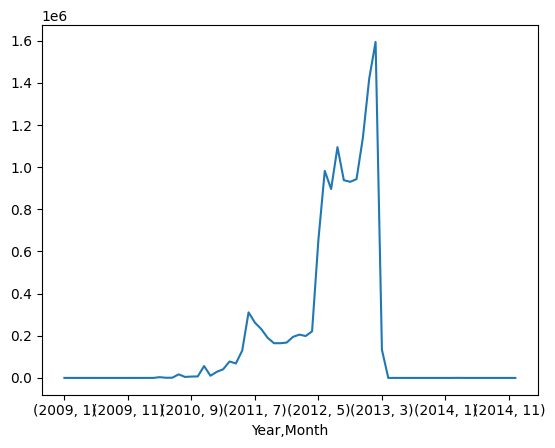

In [ ]:
%%time

# Essa solução demora um pouco mais de tempo para executar, provavelmente porque
# existem vários anos e meses com poucos registros, gerando uma carga de carregamento
# de vários conjuntos de dados pequenos.

bitcoin_df.groupby(['Year', 'Month'], sort=True)\
    ['Height']\
    .count()\
    .rename('Transactions_Count')\
    .compute()\
    .plot()

In [ ]:
bitcoin_df = dd.read_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet_clean', engine='pyarrow')
bitcoin_df

,Height,Sum,Time,Date,Year,Month,Day,Weekday
npartitions=23,,,,,,,,
,float64,float64,datetime64[ns],string,int32,int32,int32,int32
,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...


In [ ]:
# Vamos criar uma nova coluna 'Year_Month' que é a concatenação do 'Year' com 'Month'

bitcoin_df['Year_Month'] = bitcoin_df['Year'].astype(str) +\
                           bitcoin_df['Month'].astype(str).str.zfill(2)
bitcoin_df.head()

,Height,Sum,Time,Date,Year,Month,Day,Weekday,Year_Month
0,546.00,25.00,2009-01-15 06:08:20,2009-01-15,2009,1,15,3,200901
1,546.00,25.00,2009-01-15 06:08:20,2009-01-15,2009,1,15,3,200901
2,546.00,25.00,2009-01-15 06:08:20,2009-01-15,2009,1,15,3,200901
3,586.00,250.00,2009-01-15 14:25:20,2009-01-15,2009,1,15,3,200901
4,586.00,50.00,2009-01-15 14:25:20,2009-01-15,2009,1,15,3,200901


In [ ]:
%%time

# Agora vamos criar uma lista ordenada com todos os valores existentes na coluna 'Year_Month'

year_month_list = bitcoin_df['Year_Month']\
    .unique()\
    .compute()\
    .tolist()
year_month_list = sorted(year_month_list)
print(year_month_list)

['200901', '200902', '200903', '200904', '200905', '200908', '200910', '200911', '200912', '201001', '201002', '201003', '201004', '201005', '201006', '201007', '201008', '201009', '201010', '201011', '201012', '201101', '201102', '201103', '201104', '201105', '201106', '201107', '201108', '201109', '201110', '201111', '201112', '201201', '201202', '201203', '201204', '201205', '201206', '201207', '201208', '201209', '201210', '201211', '201212', '201301', '201302', '201303', '201305', '201403']
CPU times: user 928 ms, sys: 99.4 ms, total: 1.03 s
Wall time: 16.9 s


In [ ]:
len(year_month_list)

50

In [ ]:
%%time

# Com a coluna nova 'Year_Month', nós podemos colocar ela como índice e fazer um repartition
# usando o argumento divisions. Dessa forma nós garantimos que cada ano e mês tem seus dados
# em uma determinada partição.

bitcoin_df.set_index('Year_Month')\
    .repartition(divisions=year_month_list)\
    .to_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet_year_month_idx',
                overwrite=True,
                engine='pyarrow')

CPU times: user 6.74 s, sys: 849 ms, total: 7.59 s
Wall time: 2min


In [ ]:
bitcoin_df = dd.read_parquet(f'{ROOT_DATA_PATH}/bitcoin_parquet_year_month_idx', engine='pyarrow')
bitcoin_df

,Height,Sum,Time,Date,Year,Month,Day,Weekday
npartitions=49,,,,,,,,
,float64,float64,datetime64[ns],string,int32,int32,int32,int32
,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...


In [ ]:
bitcoin_df.head()

,Height,Sum,Time,Date,Year,Month,Day,Weekday
Year_Month,,,,,,,,
200901,546.00,25.00,2009-01-15 06:08:20,2009-01-15,2009,1,15,3
200901,546.00,25.00,2009-01-15 06:08:20,2009-01-15,2009,1,15,3
200901,546.00,25.00,2009-01-15 06:08:20,2009-01-15,2009,1,15,3
200901,586.00,250.00,2009-01-15 14:25:20,2009-01-15,2009,1,15,3
200901,586.00,50.00,2009-01-15 14:25:20,2009-01-15,2009,1,15,3


In [ ]:
bitcoin_df.tail()

,Height,Sum,Time,Date,Year,Month,Day,Weekday
Year_Month,,,,,,,,
201403,162725.00,6.76,2014-03-03 13:38:05,2014-03-03,2014,3,3,0
201403,162725.00,3.58,2014-03-03 13:38:05,2014-03-03,2014,3,3,0
201403,162725.00,3.35,2014-03-03 13:38:05,2014-03-03,2014,3,3,0
201403,162725.00,0.69,2014-03-03 13:38:05,2014-03-03,2014,3,3,0
201403,188245.00,418.02,2014-03-03 14:59:11,2014-03-03,2014,3,3,0


CPU times: user 310 ms, sys: 36.8 ms, total: 347 ms
Wall time: 4.64 s


<Axes: xlabel='Year_Month'>

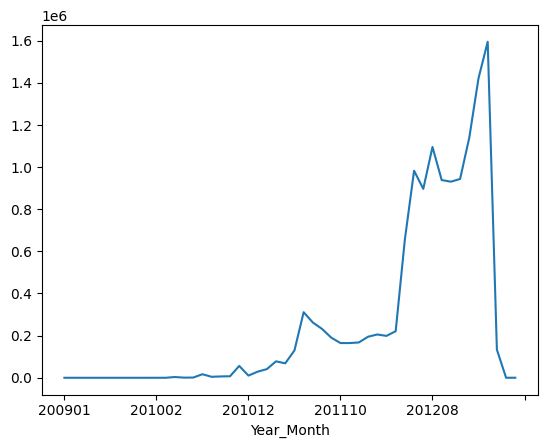

In [ ]:
%%time

bitcoin_df.groupby('Year_Month')\
    ['Height']\
    .count()\
    .rename('Transactions_Count')\
    .compute()\
    .plot()